# 二手房价回归预测

本Notebook整合Ames Housing数据清洗、探索性数据分析、传统机器学习建模、PyTorch深度学习建模和模型对比。代码固定随机种子 `42`，从原始数据加载开始，到最终指标和图表输出结束，可在重启内核后顺序运行。

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from lightgbm import LGBMRegressor
except Exception:
    LGBMRegressor = None

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
DATA_PATH = Path('AmesHousing.csv')
OUTPUT_DIR = Path('output/final')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

set_seed()
sns.set_theme(style='whitegrid')
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch: 2.12.0+cu126
CUDA available: True


## 1. 数据加载与清洗

数据集使用UCI Ames Housing原始CSV。清洗阶段移除标识列，处理缺失值，对房价和少量强偏态面积变量做温和截断，并生成 `LogSalePrice` 作为建模目标。

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print('原始数据形状:', raw_df.shape)
display(raw_df.head())

df = raw_df.copy()
df = df.drop(columns=[c for c in ['Order', 'PID'] if c in df.columns])
df = df.replace(['', 'NA', 'N/A', 'None', 'null'], np.nan)

missing_before = df.isna().sum().sort_values(ascending=False)
missing_before = missing_before[missing_before > 0]
display(missing_before.head(20).to_frame('missing_count'))

numeric_cols_with_missing = df.select_dtypes(include=[np.number]).columns[df.select_dtypes(include=[np.number]).isna().any()].tolist()
for col in numeric_cols_with_missing:
    df[f'{col}_missing'] = df[col].isna().astype(int)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    df[col] = df[col].fillna('Missing')

for col in ['SalePrice', 'Lot Area', 'Gr Liv Area', 'Total Bsmt SF', '1st Flr SF']:
    if col in df.columns:
        low, high = df[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(low, high)

df['LogSalePrice'] = np.log(df['SalePrice'])
df.to_csv('AmesHousing_Cleaned.csv', index=False, encoding='utf-8-sig')
print('清洗后数据形状:', df.shape)
print('剩余缺失值:', int(df.isna().sum().sum()))
display(df[['SalePrice', 'LogSalePrice']].describe())

原始数据形状: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


,missing_count
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Yr Blt,159
Garage Qual,159
Garage Cond,159


清洗后数据形状: (2930, 92)
剩余缺失值: 0


,SalePrice,LogSalePrice
count,2930.000000,2930.000000
mean,180091.154334,12.022394
std,75842.579174,0.392550
min,61756.070000,11.030948
25%,129500.000000,11.771436
50%,160000.000000,11.982929
75%,213500.000000,12.271392
max,456666.370000,13.031708


## 2. 探索性数据分析

EDA关注缺失模式、目标变量分布、关键数值变量箱线图以及数值特征相关性。

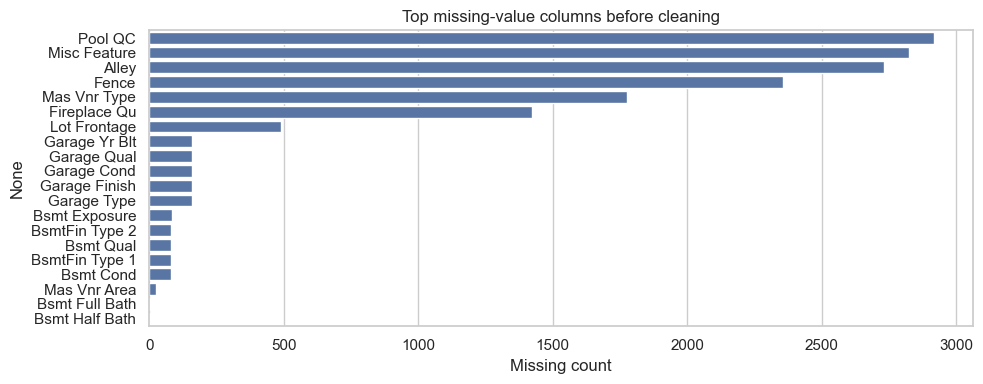

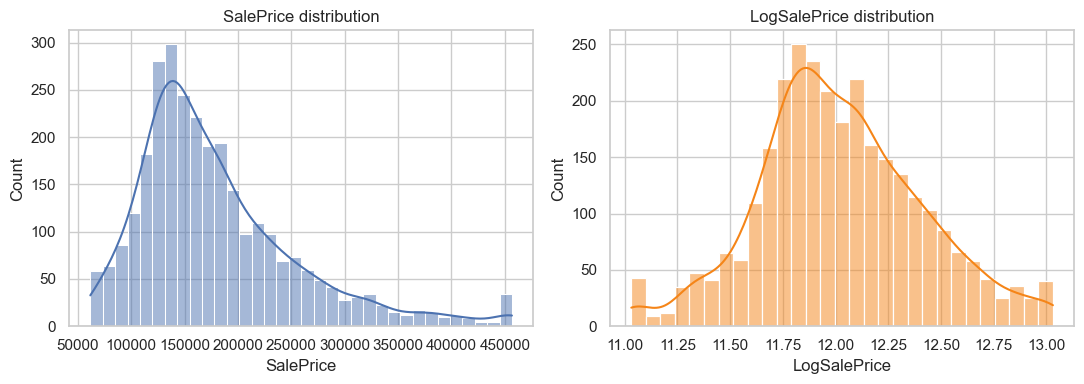

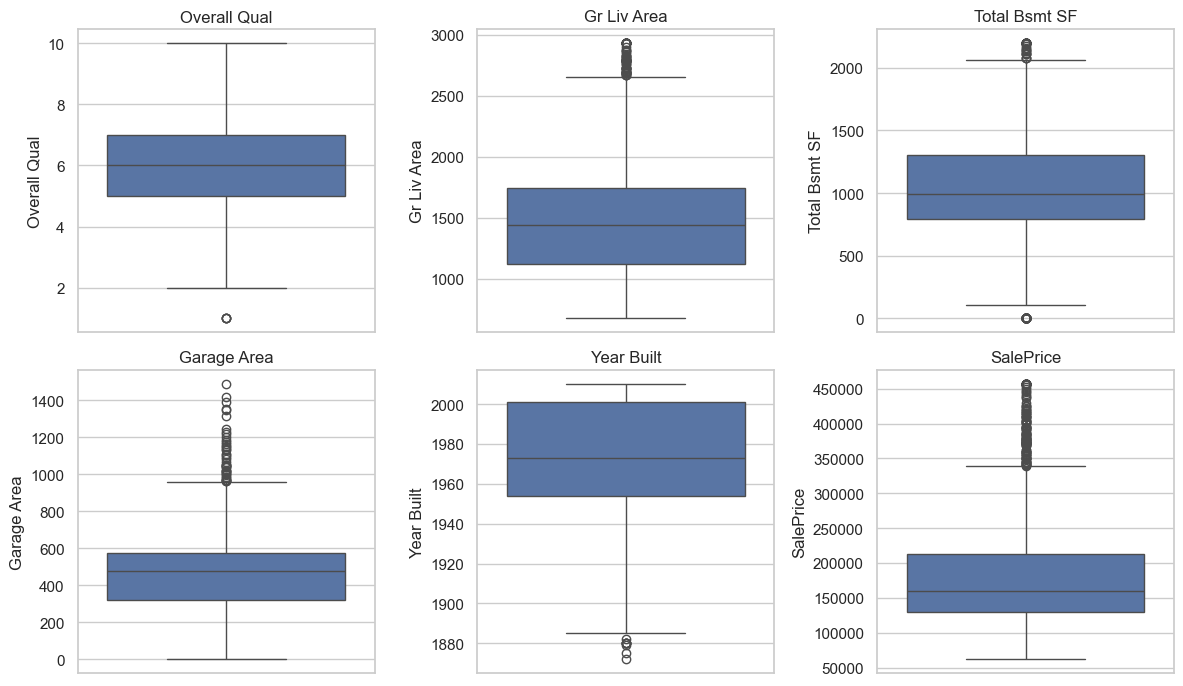

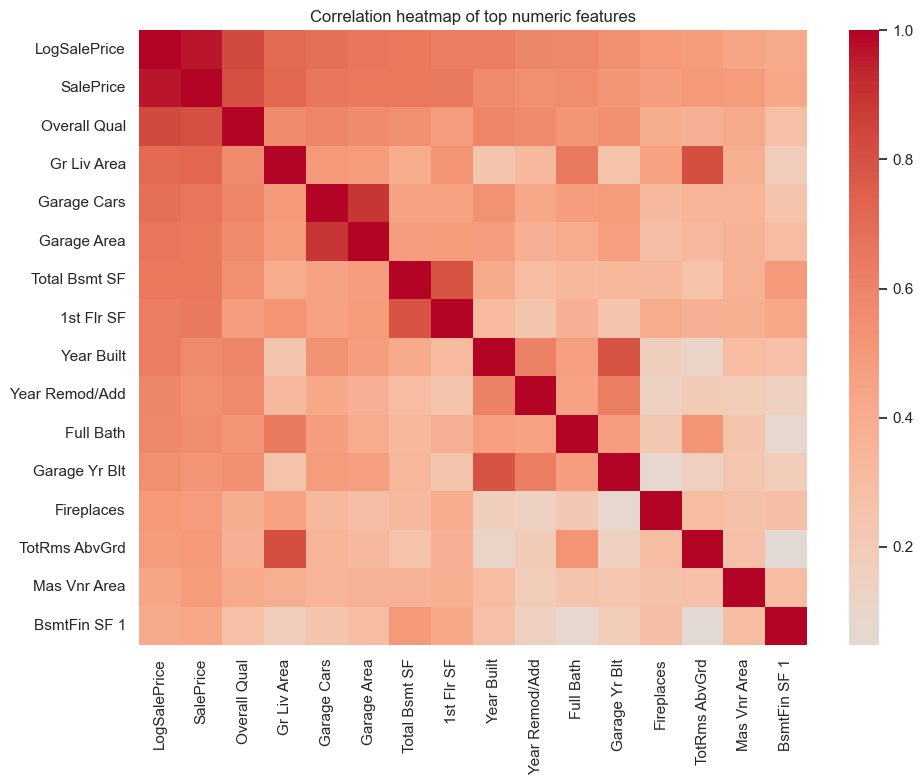

,abs_corr_with_log_price
LogSalePrice,1.000000
SalePrice,0.964209
Overall Qual,0.827040
Gr Liv Area,0.716862
Garage Cars,0.687480
Garage Area,0.663245
Total Bsmt SF,0.650347
1st Flr SF,0.626709
Year Built,0.624692
Year Remod/Add,0.594338


In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
if len(missing_before) > 0:
    sns.barplot(x=missing_before.head(20).values, y=missing_before.head(20).index, ax=ax)
    ax.set_title('Top missing-value columns before cleaning')
    ax.set_xlabel('Missing count')
else:
    ax.text(0.5, 0.5, 'No missing values detected', ha='center', va='center')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '01_missing_values.png', dpi=300)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice distribution')
sns.histplot(df['LogSalePrice'], kde=True, ax=axes[1], color='#f58518')
axes[1].set_title('LogSalePrice distribution')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '02_target_distribution.png', dpi=300)
plt.show()

box_cols = [c for c in ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Garage Area', 'Year Built', 'SalePrice'] if c in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.ravel(), box_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
for ax in axes.ravel()[len(box_cols):]:
    ax.axis('off')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '03_numeric_boxplots.png', dpi=300)
plt.show()

corr = df.select_dtypes(include=[np.number]).corr(numeric_only=True)['LogSalePrice'].abs().sort_values(ascending=False)
top_corr_cols = corr.head(16).index.tolist()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[top_corr_cols].corr(), cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation heatmap of top numeric features')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '04_correlation_heatmap.png', dpi=300)
plt.show()

display(corr.head(15).to_frame('abs_corr_with_log_price'))

## 3. 特征工程与数据划分

建模输入显式删除 `SalePrice` 和 `LogSalePrice`，防止目标泄露。分类特征使用One-Hot编码，数值特征标准化。回归任务通过目标变量分位数分箱进行近似分层划分。

In [4]:
def make_bins(y, bins=10):
    try:
        return pd.qcut(y, q=bins, labels=False, duplicates='drop')
    except ValueError:
        return None

target = df['LogSalePrice'].astype('float32')
features = df.drop(columns=['SalePrice', 'LogSalePrice'])
bins = make_bins(target)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    features, target, test_size=0.2, random_state=RANDOM_STATE, stratify=bins
)
train_val_bins = make_bins(y_train_val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=RANDOM_STATE, stratify=train_val_bins
)

categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = [c for c in X_train.columns if c not in categorical_features]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', make_ohe(), categorical_features),
    ],
    sparse_threshold=0.0,
)
print('训练/验证/测试:', X_train.shape, X_val.shape, X_test.shape)
print('数值特征:', len(numeric_features), '分类特征:', len(categorical_features))

训练/验证/测试: (1875, 90) (469, 90) (586, 90)
数值特征: 47 分类特征: 43


## 4. 传统回归模型

训练Lasso、随机森林和梯度提升树模型，并在同一测试集上比较RMSE与R²。

,model,rmse_log,r2_log
0,Lasso,0.116280,0.909624
2,LightGBM,0.117660,0.907467
1,RandomForest,0.128021,0.890452


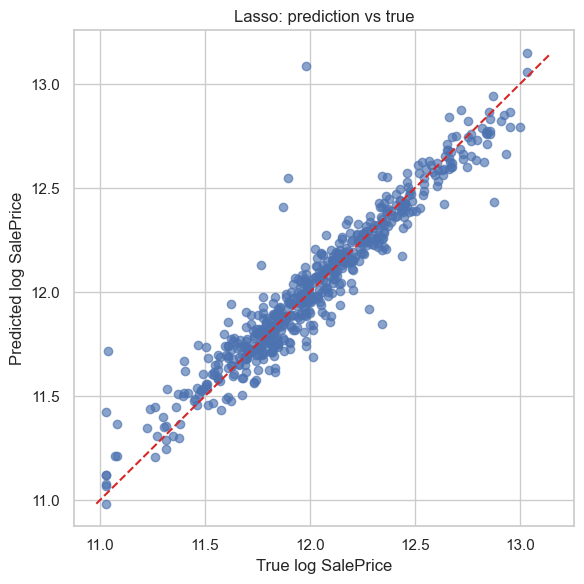

In [5]:
traditional_models = {
    'Lasso': Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=10000),
    'RandomForest': RandomForestRegressor(n_estimators=120, max_depth=None, min_samples_leaf=2, n_jobs=1, random_state=RANDOM_STATE),
}
if LGBMRegressor is not None:
    traditional_models['LightGBM'] = LGBMRegressor(n_estimators=160, learning_rate=0.05, num_leaves=31, random_state=RANDOM_STATE, n_jobs=1, verbose=-1)
else:
    traditional_models['HistGradientBoosting'] = HistGradientBoostingRegressor(max_iter=160, learning_rate=0.05, random_state=RANDOM_STATE)

traditional_results = []
fitted_pipelines = {}
for name, model in traditional_models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    traditional_results.append({'model': name, 'rmse_log': rmse(y_test, pred), 'r2_log': r2_score(y_test, pred)})
    fitted_pipelines[name] = pipe

traditional_results_df = pd.DataFrame(traditional_results).sort_values('rmse_log')
traditional_results_df.to_csv(OUTPUT_DIR / 'traditional_model_results.csv', index=False, encoding='utf-8-sig')
display(traditional_results_df)

best_traditional_name = traditional_results_df.iloc[0]['model']
best_traditional_pipe = fitted_pipelines[best_traditional_name]
best_traditional_pred = best_traditional_pipe.predict(X_test)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, best_traditional_pred, alpha=0.65)
line_min = min(y_test.min(), best_traditional_pred.min())
line_max = max(y_test.max(), best_traditional_pred.max())
ax.plot([line_min, line_max], [line_min, line_max], '--', color='#d62728')
ax.set_title(f'{best_traditional_name}: prediction vs true')
ax.set_xlabel('True log SalePrice')
ax.set_ylabel('Predicted log SalePrice')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '05_best_traditional_prediction.png', dpi=300)
plt.show()

## 5. PyTorch MLP深度学习模型

MLP使用全连接层、BatchNorm、ReLU和Dropout。目标变量在训练时标准化，预测后还原到对数房价尺度计算指标。

In [6]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 128, 64), dropout=0.15):
        super().__init__()
        layers = []
        current = input_dim
        for hidden in hidden_dims:
            layers.extend([nn.Linear(current, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout)])
            current = hidden
        layers.append(nn.Linear(current, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(1)

X_train_arr = preprocessor.fit_transform(X_train).astype('float32')
X_val_arr = preprocessor.transform(X_val).astype('float32')
X_test_arr = preprocessor.transform(X_test).astype('float32')

y_mean = float(y_train.mean())
y_std = float(y_train.std())
y_train_scaled = ((y_train - y_mean) / y_std).to_numpy(dtype='float32')
y_val_np = y_val.to_numpy(dtype='float32')
y_test_np = y_test.to_numpy(dtype='float32')

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_arr), torch.from_numpy(y_train_scaled)),
    batch_size=64,
    shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_STATE),
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLPRegressor(X_train_arr.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-5)

def predict_log(model, x_array):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(torch.from_numpy(x_array).to(device)).cpu().numpy()
    return pred_scaled * y_std + y_mean

history = []
best_state = None
best_val_rmse = float('inf')
patience = 35
patience_left = patience
for epoch in range(1, 301):
    model.train()
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.item()))
    val_pred = predict_log(model, X_val_arr)
    val_rmse = rmse(y_val_np, val_pred)
    history.append({'epoch': epoch, 'train_loss': np.mean(losses), 'val_rmse_log': val_rmse, 'val_r2_log': r2_score(y_val_np, val_pred)})
    if val_rmse < best_val_rmse - 1e-5:
        best_val_rmse = val_rmse
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_left = patience
    else:
        patience_left -= 1
    if patience_left <= 0:
        break

model.load_state_dict(best_state)
mlp_pred = predict_log(model, X_test_arr)
mlp_result = {'model': 'PyTorch_MLP', 'rmse_log': rmse(y_test_np, mlp_pred), 'r2_log': r2_score(y_test_np, mlp_pred)}
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / 'mlp_training_history.csv', index=False, encoding='utf-8-sig')
pd.DataFrame([mlp_result]).to_csv(OUTPUT_DIR / 'mlp_model_results.csv', index=False, encoding='utf-8-sig')
display(pd.DataFrame([mlp_result]))

,model,rmse_log,r2_log
0,PyTorch_MLP,0.113032,0.914603


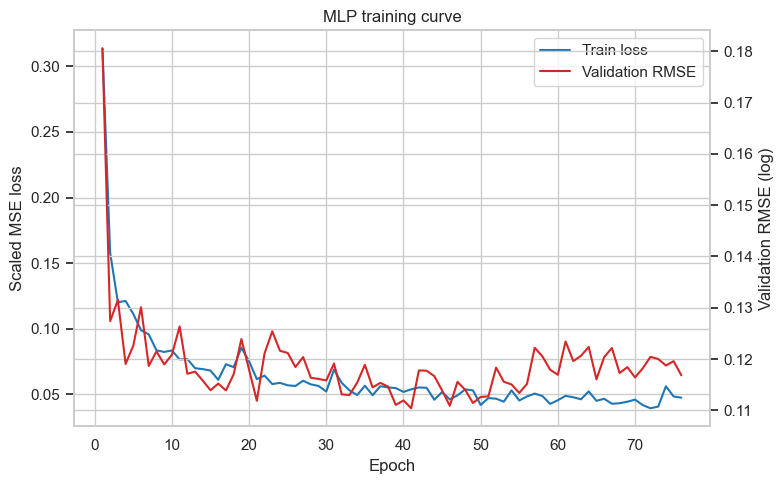

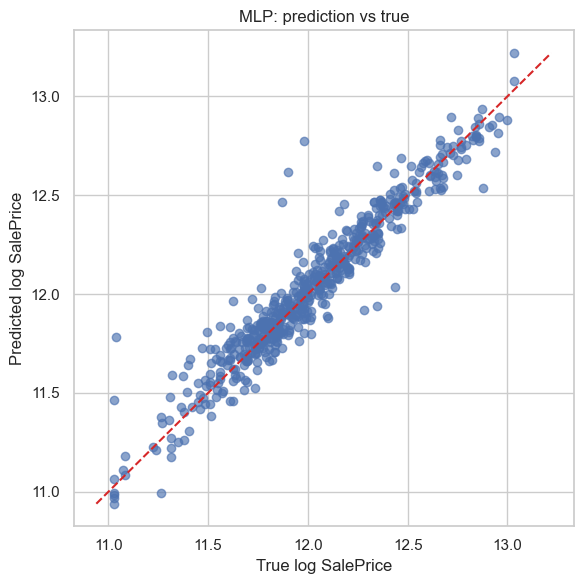

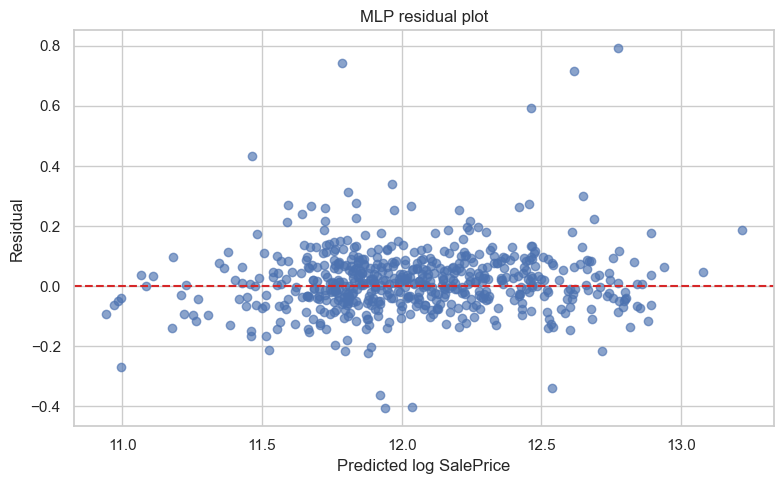

In [7]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train loss', color='#1f77b4')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Scaled MSE loss')
ax2 = ax1.twinx()
ax2.plot(history_df['epoch'], history_df['val_rmse_log'], label='Validation RMSE', color='#d62728')
ax2.set_ylabel('Validation RMSE (log)')
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc='upper right')
ax1.set_title('MLP training curve')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '06_mlp_training_curve.png', dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_np, mlp_pred, alpha=0.65)
line_min = min(y_test_np.min(), mlp_pred.min())
line_max = max(y_test_np.max(), mlp_pred.max())
ax.plot([line_min, line_max], [line_min, line_max], '--', color='#d62728')
ax.set_title('MLP: prediction vs true')
ax.set_xlabel('True log SalePrice')
ax.set_ylabel('Predicted log SalePrice')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '07_mlp_prediction_vs_true.png', dpi=300)
plt.show()

residual = mlp_pred - y_test_np
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(mlp_pred, residual, alpha=0.65)
ax.axhline(0, linestyle='--', color='#d62728')
ax.set_title('MLP residual plot')
ax.set_xlabel('Predicted log SalePrice')
ax.set_ylabel('Residual')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '08_mlp_residuals.png', dpi=300)
plt.show()

## 6. 模型对比与结论

所有模型均使用同一清洗数据、同一测试集，并排除了目标相关列。

,model,rmse_log,r2_log
0,PyTorch_MLP,0.113032,0.914603
1,Lasso,0.116280,0.909624
2,LightGBM,0.117660,0.907467
3,RandomForest,0.128021,0.890452


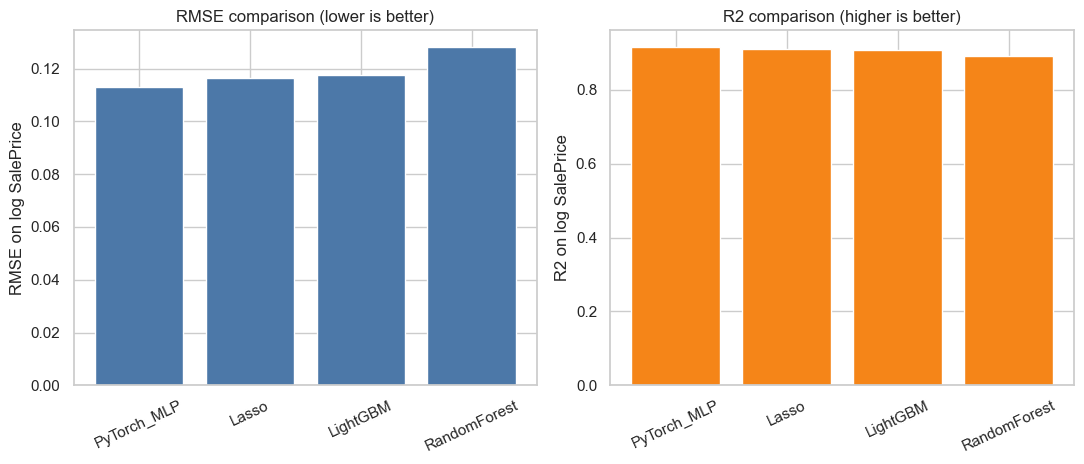

最佳模型: PyTorch_MLP, RMSE(log)=0.113032, R2(log)=0.914603


In [8]:
all_results = pd.concat([traditional_results_df, pd.DataFrame([mlp_result])], ignore_index=True)
all_results = all_results.sort_values('rmse_log').reset_index(drop=True)
all_results.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False, encoding='utf-8-sig')
display(all_results)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].bar(all_results['model'], all_results['rmse_log'], color='#4c78a8')
axes[0].set_title('RMSE comparison (lower is better)')
axes[0].set_ylabel('RMSE on log SalePrice')
axes[0].tick_params(axis='x', rotation=25)
axes[1].bar(all_results['model'], all_results['r2_log'], color='#f58518')
axes[1].set_title('R2 comparison (higher is better)')
axes[1].set_ylabel('R2 on log SalePrice')
axes[1].tick_params(axis='x', rotation=25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '09_model_comparison.png', dpi=300)
plt.show()

best_model = all_results.iloc[0]
print(f"最佳模型: {best_model['model']}, RMSE(log)={best_model['rmse_log']:.6f}, R2(log)={best_model['r2_log']:.6f}")

### 总结

- 对 `SalePrice` 做对数变换后，目标变量分布更接近正态，回归模型更容易学习。
- 本Notebook在建模前删除 `SalePrice` 与 `LogSalePrice`，避免目标泄露。
- 传统集成模型通常能较好处理表格数据中的非线性关系；MLP在标准化和正则化后也能取得稳定效果。
- 最终图表和结果表统一保存在 `output/final/`，可直接用于项目报告。